In [1]:
print('Daily calibration starting...')

Daily calibration starting...


In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2')
sys.path.insert(0, 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2\\measurement_notebooks')
import numpy as np
import matplotlib.pyplot as plt
from meas_utils import MultimodeStation
from calibration_helpers import (
    init_helpers,
    do_res_spec, update_res_spec,
    do_single_shot, update_single_shot,
    do_t2_ramsey, update_t2_ramsey_ge, update_t2_ramsey_ef,
)

station = MultimodeStation(
    experiment_name  = '2600403_lmm',
    hardware_config  = 'hardware_config_20260111.yml',
)
init_helpers(station)
config_thisrun = station.config_thisrun
cfg_dict       = station.cfg_dict
meas           = station.meas
print('Station ready.')

No module named 'visa.six.moves'
Warning VISA library import failed
Warning serial library import failed.
Could not load InstrumentManagerWindow
Could not import QickInstrument, try install qick package
Could not load AD5780 dac 
Could not load labbrick
Could not load Autonics TM4 Driver
Could not load Oxford Trition driver
connected proxies, ns= <Pyro4.core.Proxy at 0x1b2e909bcb0; connected IPv4; for PYRO:Pyro.NameServer@10.108.30.32:9090>
Path added at highest priority
['C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2', 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2\\measurement_notebooks', 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2', 'C:\\_Lib\\python', 'C:\\_Lib\\python\\slab', 'c:\\ProgramData\\Anaconda3\\envs\\mm313\\python313.zip', 'c:\\ProgramData\\Anaconda3\\envs\\mm313\\DLLs', 'c:\\ProgramData\\Anaconda3\\envs\\mm313\\Lib', 'c:\\ProgramData\\Anaconda3\\envs\\mm313', '', 'c:\\ProgramData\\Anaconda3\\envs\\mm313\\Lib\\site-packages

# VNA imports 

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from datamanagement import SlabFile
import os
print(os.getcwd())
import datetime
from time import *
# from slab import *
# from handy import prev_data
# import sys 
# project_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
# print(project_path) 
# sys.path.append(project_path) #add root path to sys.path to import fit_resonator
sys.path.insert(0, 'C:\\Users\\Administrator\\Documents\\scresonators')

# # #new_path = r'/Users/sph/Library/CloudStorage/GoogleDrive-circuitqed@gmail.com/My Drive/Projects/Materials/materials-software/'
# # new_path = r'G:/My Drive/Projects/Materials/materials-software/'
# # sys.path.append(new_path)

print(sys.path)
%load_ext autoreload
%autoreload 2
sys.path.insert(0, 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2\\vna_meas')
import vna_measurement
from ZNB import ZNB20

c:\Users\Administrator\Documents\multimode_expts_tprocv2\measurement_notebooks\device_characterization
['C:\\Users\\Administrator\\Documents\\scresonators', 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2', 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2\\measurement_notebooks', 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2', 'C:\\_Lib\\python', 'C:\\_Lib\\python\\slab', 'c:\\ProgramData\\Anaconda3\\envs\\mm313\\python313.zip', 'c:\\ProgramData\\Anaconda3\\envs\\mm313\\DLLs', 'c:\\ProgramData\\Anaconda3\\envs\\mm313\\Lib', 'c:\\ProgramData\\Anaconda3\\envs\\mm313', '', 'c:\\ProgramData\\Anaconda3\\envs\\mm313\\Lib\\site-packages']
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
station.experiment_path

WindowsPath('S:/Multimode/experiment/2600403_lmm')

In [5]:
VNA = ZNB20(address='10.108.30.65') # Stanford
#VNA = ZNB20(address='192.168.137.84') # SLAC

## Daily measurement settings
warm_att = 0 #dB
cold_att = 60

spar = 's11'

base_path = station.experiment_path #+ '\\vna_data\\' + datetime.datetime.now().strftime('%Y%m%d') + '\\'
if not os.path.exists(base_path):
    os.makedirs(base_path)

# Standard S21

Calculated line delay: 5.949248784600918e-06
fname  S:\Multimode\experiment\2600403_lmm\20260413_144830.pdf


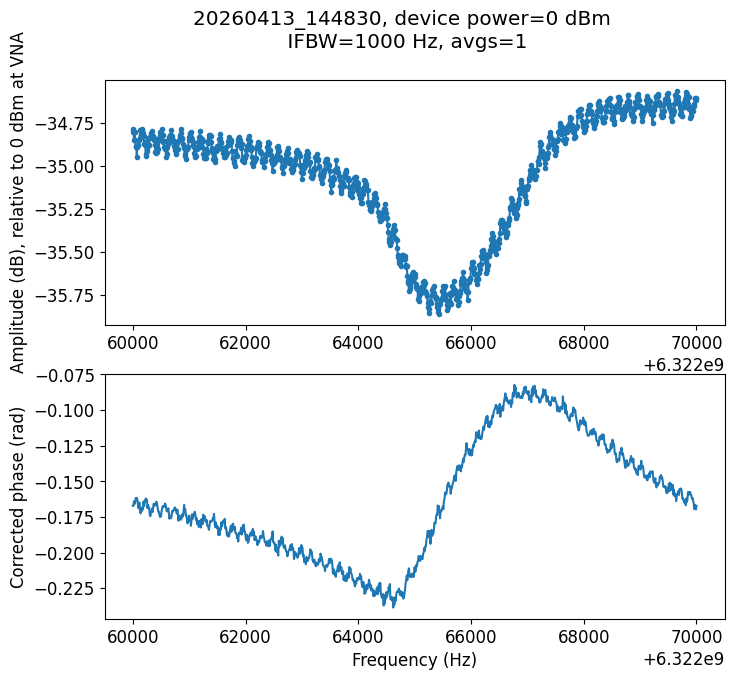

In [27]:
#%matplotlib widget
expt_path = base_path

power = 0
avgs = 1
freq_center = 6.322065e9#3.8e9 # 4.814e9
span= 1e4
bandwidth= 1000
num_points = 1001

scan_def = {'freq_center':freq_center, 'span':span,  'bandwidth':bandwidth, 'power':power, 
            'npoints':num_points, 'averages':avgs, 'spar': 'S21'}
#file_name = 'res_' + str(freq_center)[:7] + '_' + str(power)[1:] + 'dbm'
file_name = 'wide_scan'

data = vna_measurement.do_vna_scan(VNA, file_name, expt_path, scan_def,)

In [10]:
data

{'series': '20260413_142631',
 'amps': array([-34.6754, -34.7167, -34.7148, ..., -34.7031, -34.6816, -34.6446],
       shape=(11001,)),
 'phases': array([-0.1369, -0.139 , -0.1372, ..., -0.1597, -0.155 , -0.1568],
       shape=(11001,)),
 'freqs': array([6.3220e+09, 6.3220e+09, 6.3220e+09, ..., 6.3221e+09, 6.3221e+09,
        6.3221e+09], shape=(11001,)),
 'vna_power': 0,
 'power_at_device': 0,
 'bandwidth': 1000,
 'averages': 1,
 'npoints': 11001}

# VNA DC sweep 

In [28]:
"""
yoko_vna_sweep.py
Live 2D colorplot of VNA S-parameter measurement vs DC current (Yokogawa GS200).
"""

import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output


def do_yoko_vna_sweep(
    VNA,
    dcflux,
    # current sweep params
    current_start_mA  = -0.5,
    current_stop_mA   =  0.5,
    current_step_mA   =  0.01,
    # VNA scan params (per current point)
    freq_center       = 6.322e9,   # Hz
    span              = 2e4,       # Hz
    bandwidth         = 1000,      # Hz
    power             = 0,         # dBm
    npoints           = 1001,
    averages          = 1,
    spar              = 'S21',
    # display
    plot_key          = 'amps',    # 'amps' | 'phases'
    cmap              = 'RdBu_r',
    figsize           = (14, 10),
    # file saving
    expt_path         = None,      # path to save VNA data, None = don't save
    file_prefix       = 'yoko_vna_sweep',
    # safety
    ramp_to_start     = True,
    ramp_steps        = 20,
    ramp_delay_s      = 0.05,
    settle_delay_s    = 0.1,
):
    """
    Sweep Yokogawa DC current and measure a VNA S-parameter trace at each point.
    Shows a live 2D colorplot (current vs frequency) updating after each step.

    Parameters
    ----------
    VNA               : ZNB20 — connected VNA object
    dcflux            : YokogawaGS200 — connected Yoko object
    current_start_mA  : float — sweep start [mA]
    current_stop_mA   : float — sweep stop [mA]
    current_step_mA   : float — step size [mA]
    freq_center       : float — VNA center frequency [Hz]
    span              : float — VNA frequency span [Hz]
    bandwidth         : float — VNA IF bandwidth [Hz]
    power             : float — VNA output power [dBm]
    npoints           : int   — number of frequency points per scan
    averages          : int   — number of averages per scan
    spar              : str   — S-parameter to measure ('S21', 'S11', etc.)
    plot_key          : str   — 'amps' or 'phases'
    cmap              : str   — matplotlib colormap
    figsize           : tuple — figure size
    expt_path         : str or Path or None — directory to save VNA files
    file_prefix       : str   — prefix for saved VNA files
    ramp_to_start     : bool  — ramp slowly to start current before sweep
    ramp_steps        : int   — number of steps for initial ramp
    ramp_delay_s      : float — delay per ramp step [s]
    settle_delay_s    : float — settle time after each current step [s]

    Returns
    -------
    dict with keys:
        'currents'   : np.ndarray of current values [mA]
        'freqs'      : np.ndarray of frequency points [Hz]
        'amp_matrix' : 2D np.ndarray (n_currents x n_freqs) — amplitudes [dBm]
        'phase_matrix': 2D np.ndarray (n_currents x n_freqs) — phases [deg]
        'scans'      : list of raw scan dicts from vna_measurement.do_vna_scan
    """
    import vna_measurement

    currents = np.arange(current_start_mA, current_stop_mA, current_step_mA)
    n_steps  = len(currents)
    print(f'VNA sweep: {current_start_mA:.4f} → {current_stop_mA:.4f} mA, '
          f'step={current_step_mA:.4f} mA, n={n_steps}')
    print(f'Center: {freq_center*1e-9:.6f} GHz, span: {span*1e-3:.1f} kHz, '
          f'{spar}, {npoints} pts, BW={bandwidth} Hz')

    # ramp to start
    if ramp_to_start:
        ramp_current_mA(dcflux, current_start_mA)

    amp_matrix   = None
    phase_matrix = None
    freq_array   = None
    scans        = []

    scan_def = {
        'freq_center' : freq_center,
        'span'        : span,
        'bandwidth'   : bandwidth,
        'power'       : power,
        'npoints'     : npoints,
        'averages'    : averages,
        'spar'        : spar,
    }

    fig, axes = plt.subplots(2, 1, figsize=figsize)
    plt.ion()
    cbar = None

    try:
        for idx, cur_mA in enumerate(currents):
            set_current_mA(dcflux, cur_mA)
            time.sleep(settle_delay_s)
            print(f'[{idx+1}/{n_steps}]  current = {cur_mA:.4f} mA')

            # build file name if saving
            fname = None
            if expt_path is not None:
                fname = f'{file_prefix}_{idx:04d}_{cur_mA:.4f}mA'

            scan = vna_measurement.do_vna_scan(
                VNA, fname, expt_path, scan_def
            ) if expt_path is not None else vna_measurement.do_vna_scan(
                VNA, f'{file_prefix}_{idx:04d}', None, scan_def
            )
            scans.append(scan)

            freqs  = np.array(scan['freqs'])
            amps   = np.array(scan['amps'])
            phases = np.array(scan['phases'])

            if amp_matrix is None:
                freq_array   = freqs
                amp_matrix   = np.full((n_steps, len(freqs)), np.nan)
                phase_matrix = np.full((n_steps, len(freqs)), np.nan)

            amp_matrix[idx]   = amps
            phase_matrix[idx] = phases

            # ── live plot ─────────────────────────────────────────
            axes[0].cla()
            axes[1].cla()

            filled       = idx + 1
            plot_matrix  = amp_matrix if plot_key == 'amps' else phase_matrix
            ylabel_label = 'Amplitude (dBm)' if plot_key == 'amps' else 'Phase (deg)'

            im = axes[0].pcolormesh(
                freq_array * 1e-9,          # convert to GHz for display
                currents[:filled],
                plot_matrix[:filled],
                shading = 'auto',
                cmap    = cmap,
            )
            axes[0].set_xlabel('Frequency (GHz)', fontsize=12)
            axes[0].set_ylabel('DC Current (mA)', fontsize=12)
            axes[0].set_title(
                f'VNA {spar} vs Yoko current [{plot_key}]  '
                f'({filled}/{n_steps})  |  center={freq_center*1e-9:.4f} GHz',
                fontsize=12,
            )
            if cbar is None:
                cbar = fig.colorbar(im, ax=axes[0], label=ylabel_label)
            else:
                cbar.update_normal(im)

            # bottom panel: peak frequency vs current
            peak_freqs_GHz = [
                scans[i]['freqs'][np.argmin(np.array(scans[i]['amps']))] * 1e-9
                for i in range(filled)
            ]
            axes[1].plot(currents[:filled], peak_freqs_GHz, 'o-', color='C1', ms=4)
            axes[1].set_xlabel('DC Current (mA)', fontsize=12)
            axes[1].set_ylabel('Min amplitude frequency (GHz)', fontsize=12)
            axes[1].set_title('Resonance frequency vs current', fontsize=12)
            axes[1].grid(True, alpha=0.3)

            fig.tight_layout()
            clear_output(wait=True)
            display(fig)

    except KeyboardInterrupt:
        print('\nSweep interrupted by user.')

    finally:
        dcflux.set_output(False)
        print('Yoko output OFF.')

    plt.ioff()
    print(f'\nSweep complete. {len(scans)}/{n_steps} points acquired.')

    return {
        'currents'     : currents[:len(scans)],
        'freqs'        : freq_array,
        'amp_matrix'   : amp_matrix[:len(scans)] if amp_matrix is not None else None,
        'phase_matrix' : phase_matrix[:len(scans)] if phase_matrix is not None else None,
        'scans'        : scans,
    }


def replot_yoko_vna_sweep(
    result,
    cmap    = 'RdBu_r',
    clim    = None,     # dict {'amps': (vmin, vmax), 'phases': (vmin, vmax)}
                        # or single tuple applied to both, or None for auto
    figsize = (14, 10),
):
    """
    Re-plot a completed Yoko VNA sweep showing amplitude and phase side by side.
    Useful for adjusting colorscale after the fact.

    Parameters
    ----------
    result  : dict returned by do_yoko_vna_sweep
    cmap    : str   — colormap
    clim    : dict, tuple, or None — color limits per panel
    figsize : tuple
    """
    currents     = result['currents']
    freqs_GHz    = result['freqs'] * 1e-9
    amp_matrix   = result['amp_matrix']
    phase_matrix = result['phase_matrix']

    if clim is None:
        clims = {'amps': None, 'phases': None}
    elif isinstance(clim, tuple):
        clims = {'amps': clim, 'phases': clim}
    else:
        clims = clim

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    for ax, matrix, key, label in zip(
        axes,
        [amp_matrix, phase_matrix],
        ['amps', 'phases'],
        ['Amplitude (dBm)', 'Phase (deg)'],
    ):
        im = ax.pcolormesh(freqs_GHz, currents, matrix, shading='auto', cmap=cmap)
        if clims.get(key) is not None:
            im.set_clim(*clims[key])
        fig.colorbar(im, ax=ax, label=label, fraction=0.046, pad=0.04)
        ax.set_xlabel('Frequency (GHz)', fontsize=11)
        ax.set_title(label, fontsize=11)

    axes[0].set_ylabel('DC Current (mA)', fontsize=11)
    fig.tight_layout()
    plt.show()
    return fig


# ── internal helpers ──────────────────────────────────────────────────────────


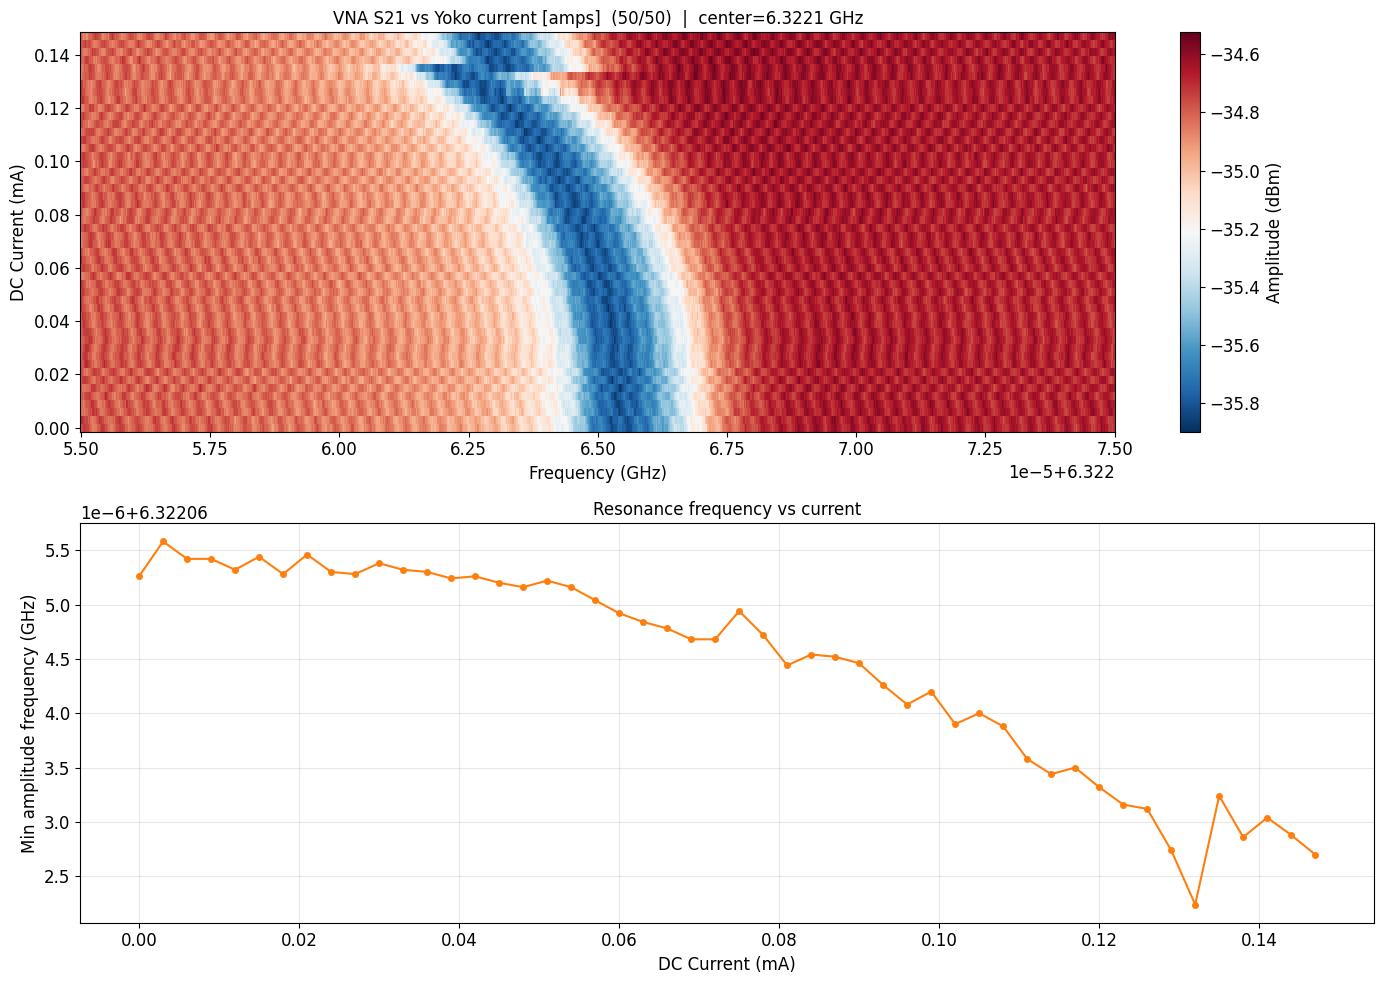

Yoko output OFF.

Sweep complete. 50/50 points acquired.


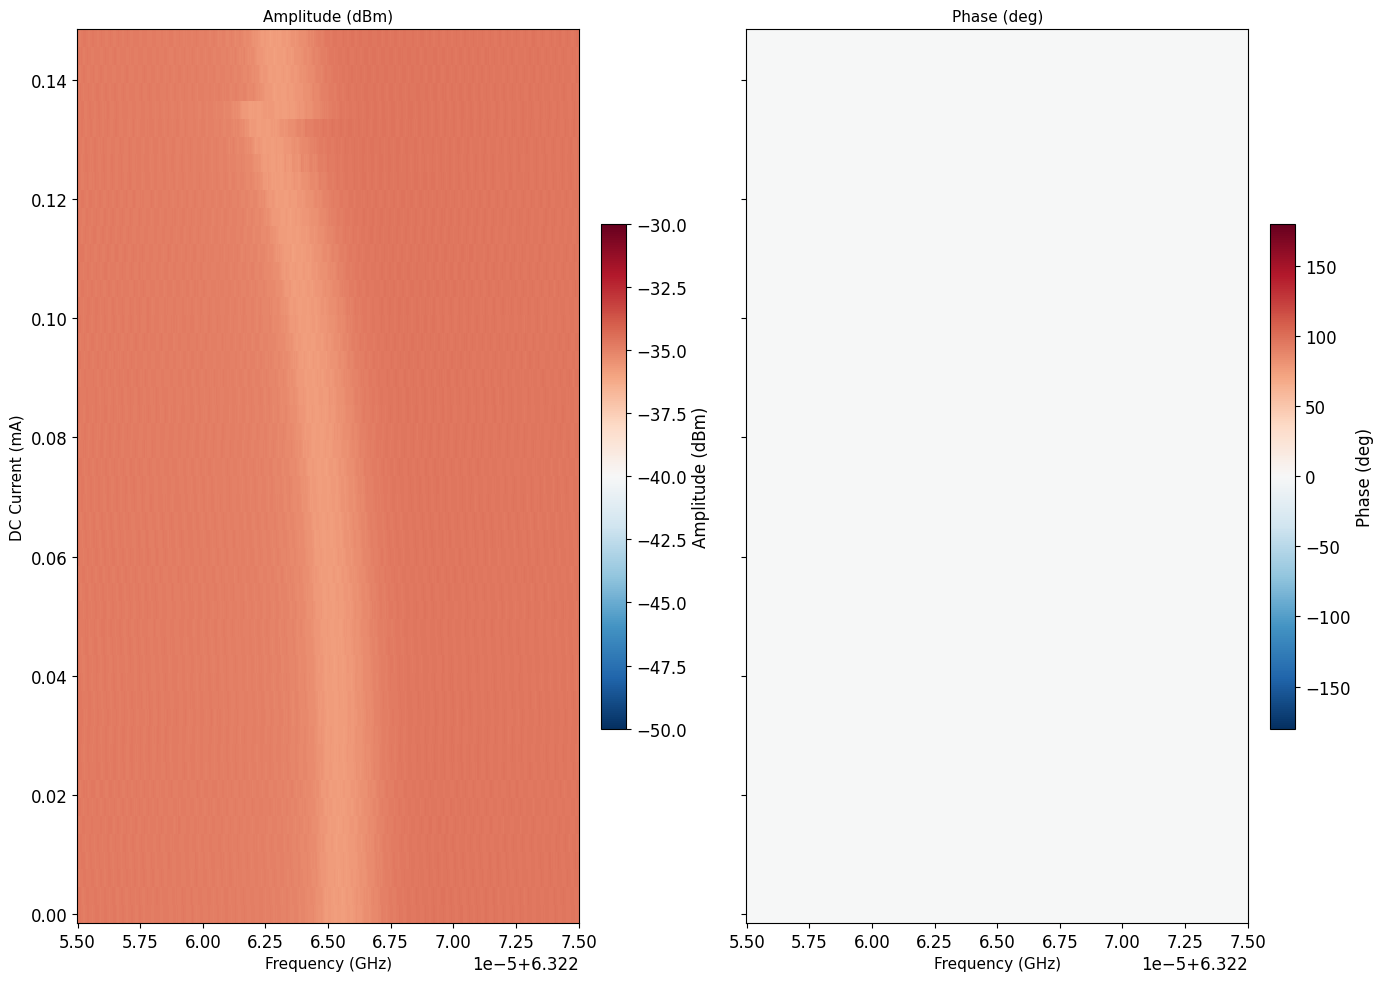

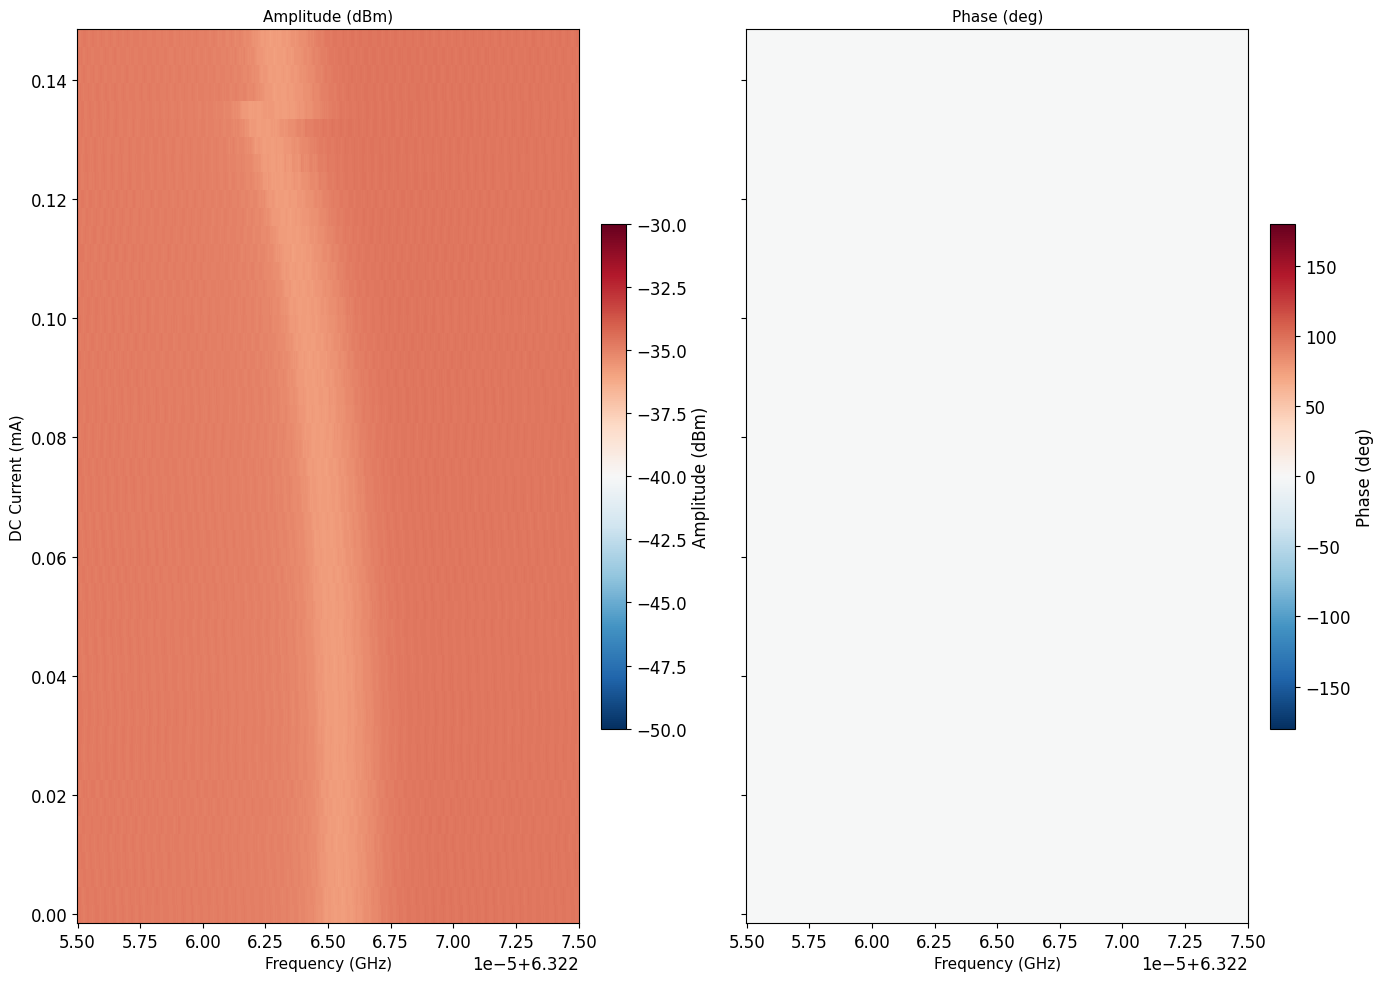

In [30]:

# from yoko_current_sweep import * 
# dcflux = connect_yoko(address='10.108.30.37')
dcflux.set_output(True)
dcflux.set_mode('current')

result = do_yoko_vna_sweep(
    VNA              = VNA,
    dcflux           = dcflux,
    current_start_mA = 0,
    current_stop_mA  =  0.15,
    current_step_mA  =  0.003,
    freq_center      = 6.322065e9,
    span             = 2e4,
    bandwidth        = 1000,
    power            = 0,
    npoints          = 1001,
    averages         = 1,
    spar             = 'S21',
    plot_key         = 'amps',
    expt_path        = station.experiment_path,
    ramp_to_start    = True,
)

# re-plot with adjusted colorscale
replot_yoko_vna_sweep(
    result,
    clim = {'amps': (-50, -30), 'phases': (-180, 180)},
)

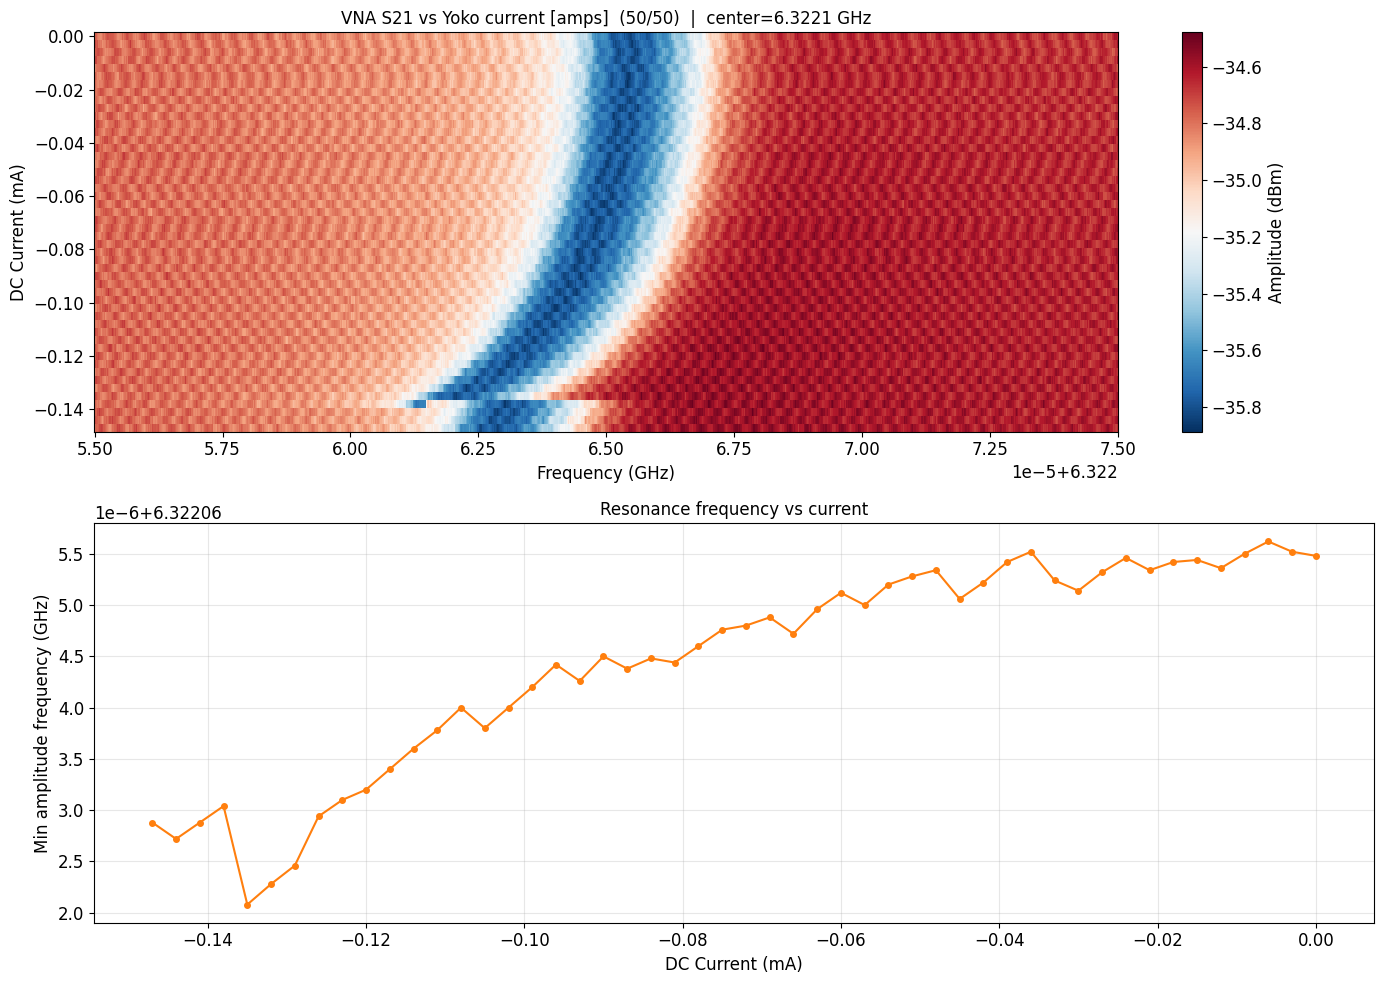

Yoko output OFF.

Sweep complete. 50/50 points acquired.


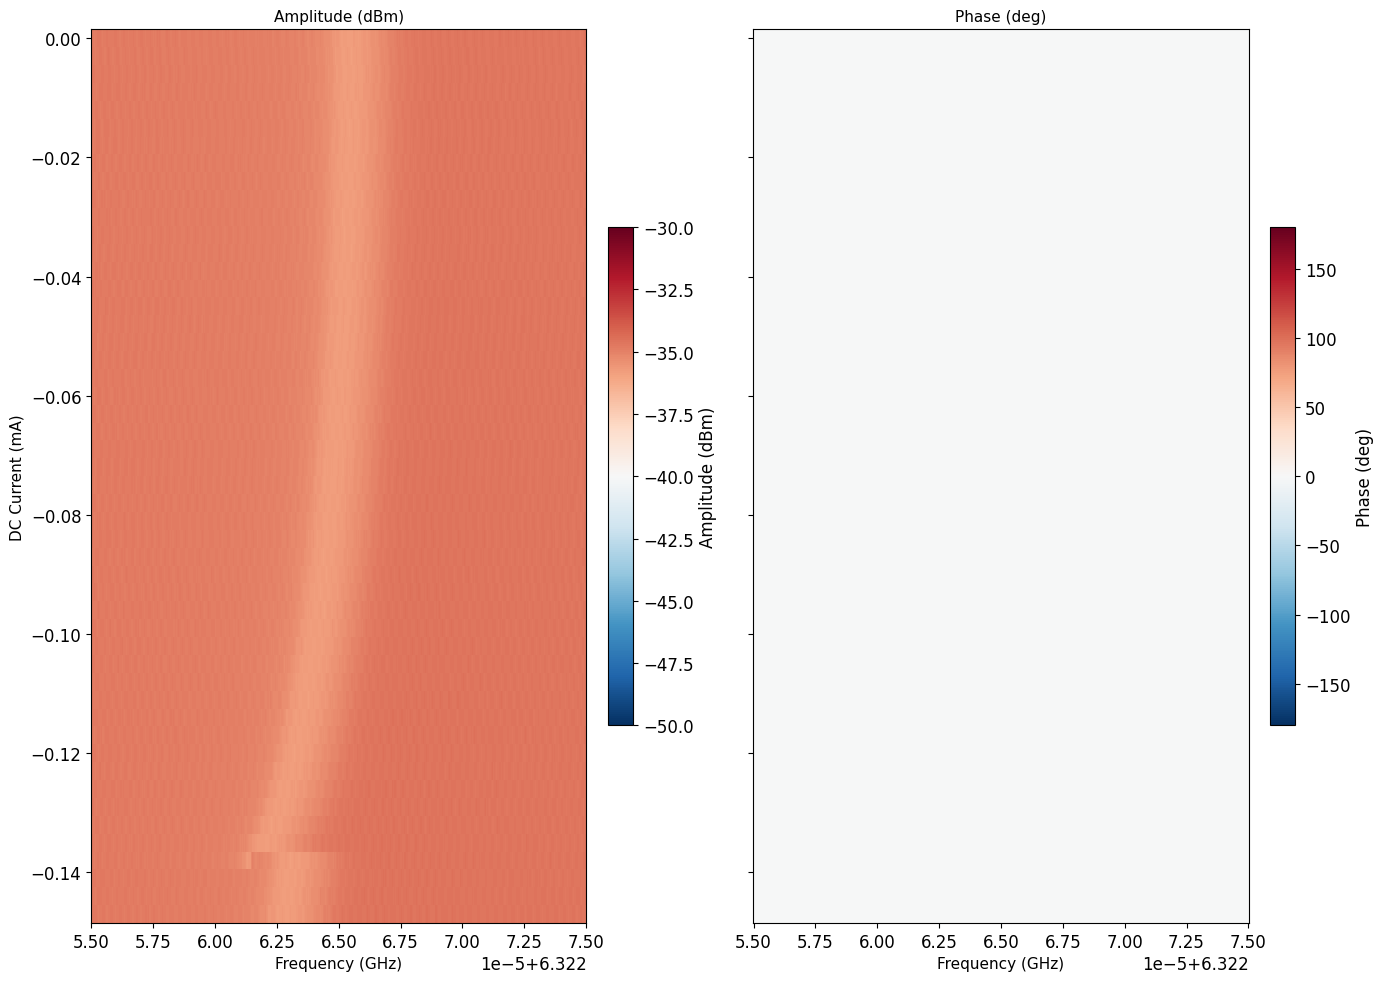

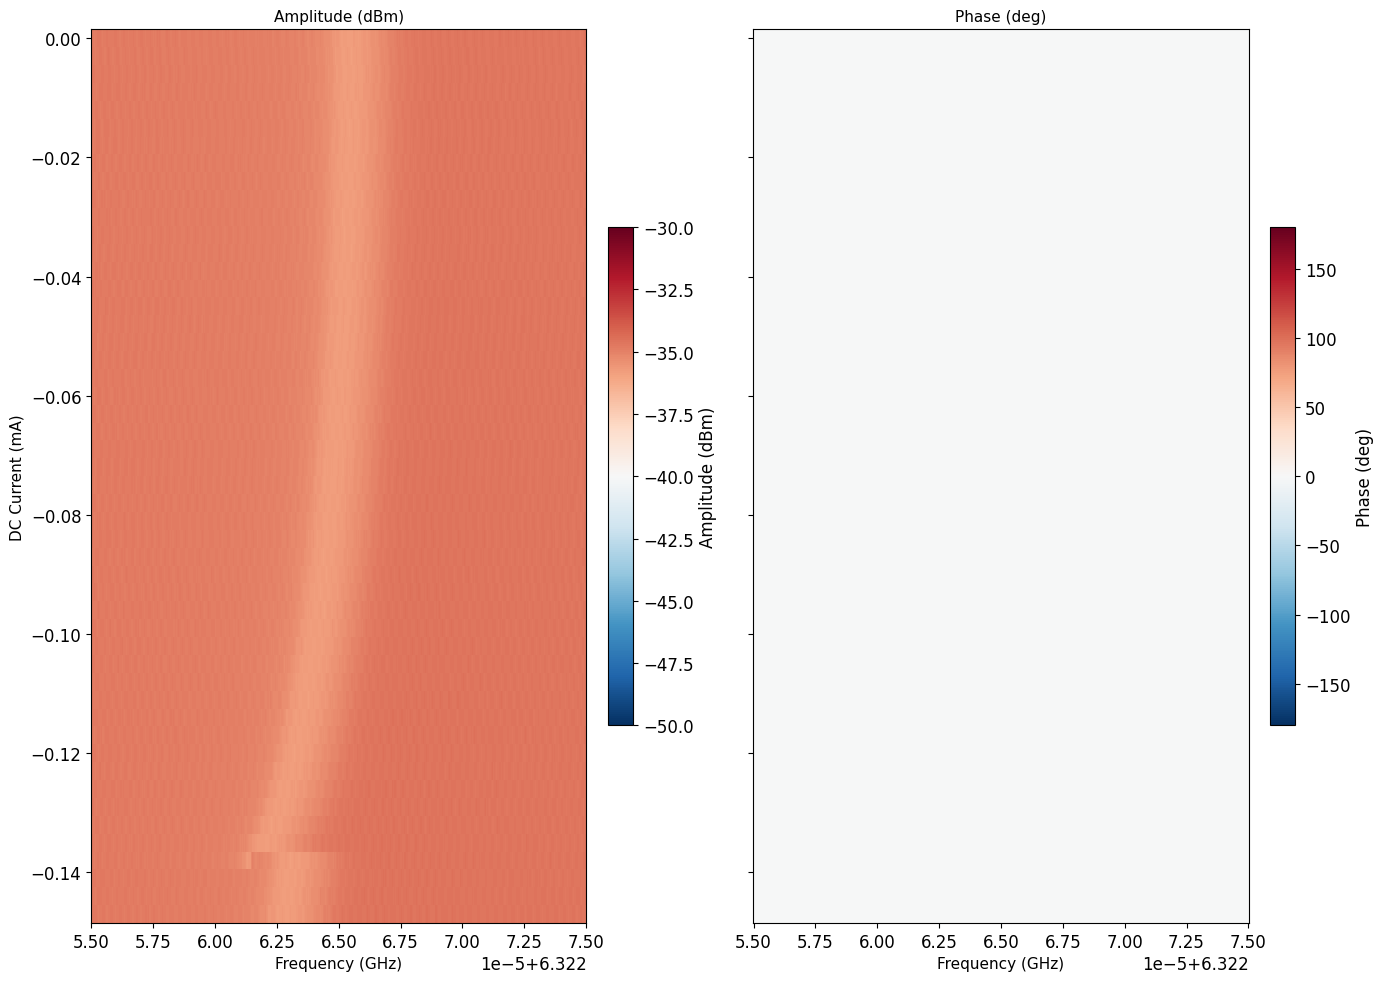

In [32]:
from yoko_current_sweep import * 
# dcflux = connect_yoko(address='10.108.30.37')
dcflux.set_output(True)
dcflux.set_mode('current')

result = do_yoko_vna_sweep(
    VNA              = VNA,
    dcflux           = dcflux,
    current_start_mA = 0,
    current_stop_mA  =  -0.15,
    current_step_mA  =  -0.003,
    freq_center      = 6.322065e9,
    span             = 2e4,
    bandwidth        = 1000,
    power            = 0,
    npoints          = 1001,
    averages         = 1,
    spar             = 'S21',
    plot_key         = 'amps',
    expt_path        = station.experiment_path,
    ramp_to_start    = True,
)

# re-plot with adjusted colorscale
replot_yoko_vna_sweep(
    result,
    clim = {'amps': (-50, -30), 'phases': (-180, 180)},
)

In [14]:

from yoko_current_sweep import * 
dcflux = connect_yoko(address='10.108.30.37')

Connected to Yokogawa at 10.108.30.37
Current output: -0.0124 mA


In [23]:
dcflux.get_current()

-0.00013499

In [20]:
ramp_current_mA(dcflux, 0.0)

Ramping 0.1000 → 0.0000 mA  (0.01 mA/s, ETA 10.0s)
Done. Current: 0.0000 mA
